# Phase 1: Import & Explore the Dataset (EDA)

In [84]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data for stopwords and lemmatization
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')




from sklearn.utils.class_weight import compute_class_weight


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


from tensorflow.keras.layers import LSTM , SimpleRNN , GRU

from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer

import torch

from torch.utils.data import Dataset

from transformers import Trainer
import torch.nn as nn

from transformers import TrainingArguments, EarlyStoppingCallback

import pickle




from kaggle_secrets import UserSecretsClient
from huggingface_hub import login


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
!pip install -q transformers datasets accelerate

###  Load the dataset

In [3]:

df = pd.read_csv('/kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv')

df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name


In [4]:
# Drop the unneeded index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Display dataset shape and the first 5 rows
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


## Data Quality Check (Nulls & Duplicates)

In [5]:
# Check for missing values in all columns
print("Missing Values:\n", df.isnull().sum())

# Count total duplicated rows in the dataset
print("\nNumber of Duplicates:", df.duplicated().sum())

Missing Values:
 product       0
narrative    10
dtype: int64

Number of Duplicates: 37742


## EDA: Class Distribution & Word Count Analysis

### 1. Plot the distribution of complaint categories (Target Variable)

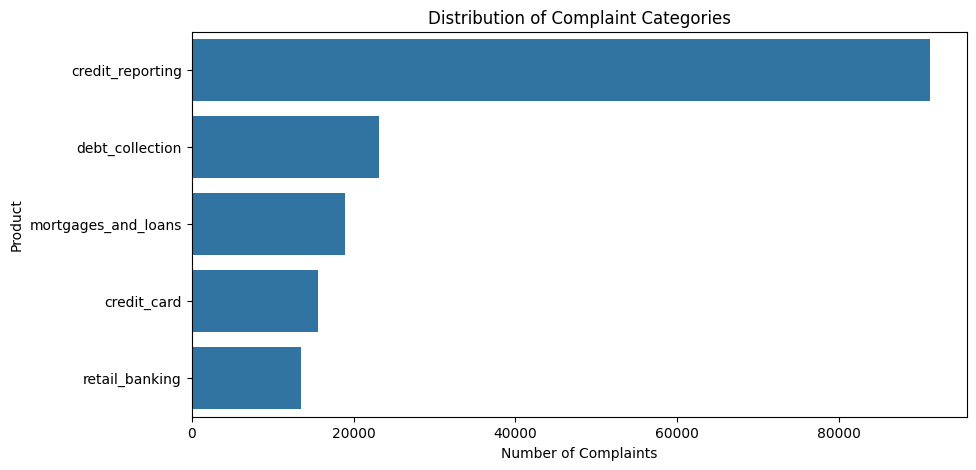

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='product', order=df['product'].value_counts().index)
plt.title('Distribution of Complaint Categories')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.show()

### 2. Calculate word count for each complaint narrative

In [6]:
df['word_count'] = df['narrative'].apply(lambda x: len(str(x).split()))

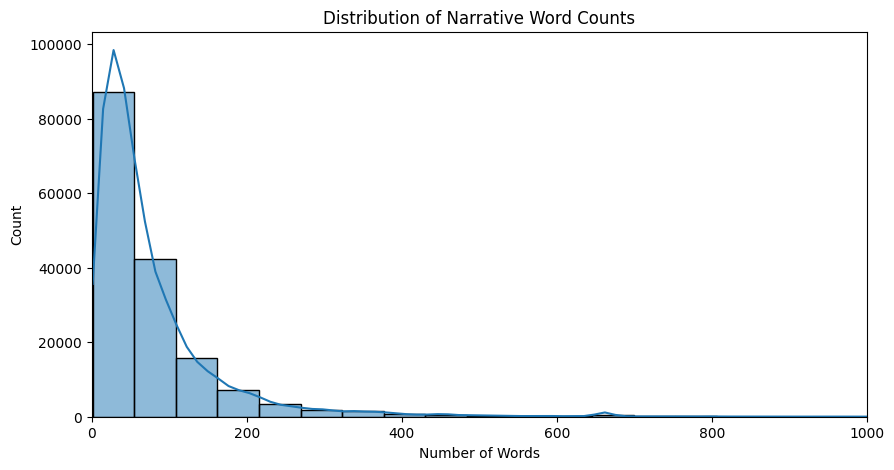

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title('Distribution of Narrative Word Counts')
plt.xlabel('Number of Words')
plt.xlim(0, 1000) 
plt.show()

## Clean Missing Values & Duplicates

In [7]:
# Drop rows with missing values in the 'narrative' column
df = df.dropna(subset=['narrative'])

# Drop exact duplicate rows to prevent data leakage and overfitting
df = df.drop_duplicates()

# Verify the new shape of the dataset after cleaning
print("Dataset Shape after cleaning:", df.shape)

Dataset Shape after cleaning: (124676, 3)


### Enhanced EDA: Word Count Distribution & Percentiles

In [8]:
# Recalculate word count just to be safe after dropping rows
df['word_count'] = df['narrative'].apply(lambda x: len(str(x).split()))

# Calculate the 95th percentile to find a meaningful MAX_LEN for our models
percentile_95 = np.percentile(df['word_count'], 95)
print(f"95% of the complaints have {int(percentile_95)} words or fewer.")

95% of the complaints have 252 words or fewer.


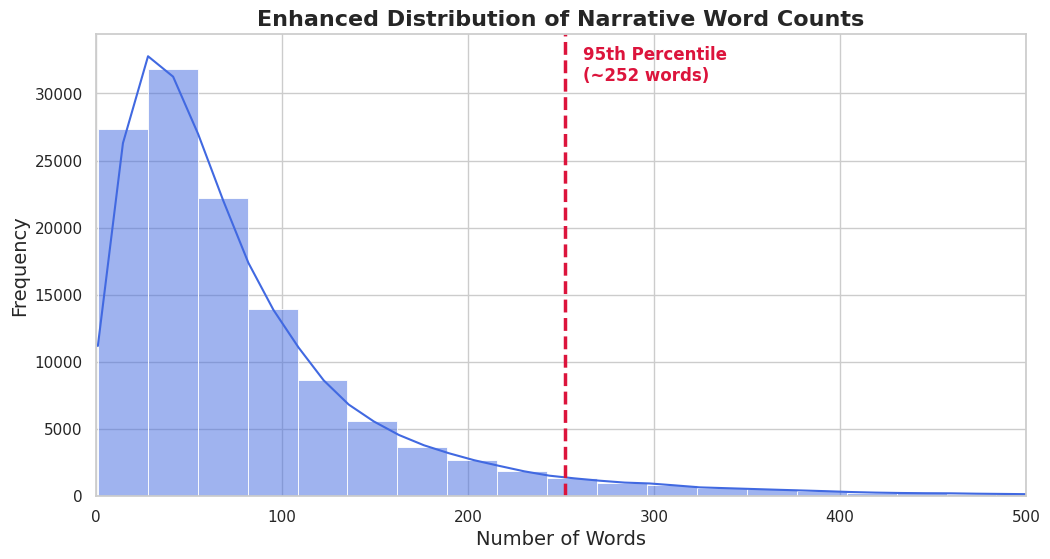

In [10]:
# Set a beautiful theme for the plot
sns.set_theme(style="whitegrid", palette="husl")

# Create a larger, colorful figure
plt.figure(figsize=(12, 6))

# Plot the histogram, zooming in on the range (0 to 500) to see the details clearly
sns.histplot(df['word_count'], bins=100, kde=True, color='royalblue')

# Add a vertical red dashed line representing the 95th percentile
plt.axvline(percentile_95, color='crimson', linestyle='dashed', linewidth=2.5)

# Add text to explain the red line on the graph
plt.text(percentile_95 + 10, plt.ylim()[1] * 0.9, 
         f'95th Percentile\n(~{int(percentile_95)} words)', 
         color='crimson', fontsize=12, fontweight='bold')

# Add titles and labels with larger fonts
plt.title('Enhanced Distribution of Narrative Word Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Limit X-axis to 500 to remove the long empty tail and focus on the bulk of the data
plt.xlim(0, 500)

plt.show()

# Phase 2: Text Preprocessing

## Define the Text Cleaning Function

In [10]:
# Initialize the lemmatizer and define the English stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Convert text to lowercase
    text = str(text).lower()
    
    # 2. Remove punctuation, special characters, and numbers
    # This regex [^a-z\s] replaces anything that is NOT a lowercase letter or space with a space
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 3. Tokenize (split text into words)
    words = text.split()
    
    # 4. Remove stopwords and lemmatize the remaining words
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # 5. Join the cleaned words back into a single string
    return ' '.join(cleaned_words)

# Test the function on a sample sentence to see how it works before applying to all data
sample_text = "I have been calling them 5 times! They are NOT helping me with my credit report."
print("Original:", sample_text)
print("Cleaned:", clean_text(sample_text))

Original: I have been calling them 5 times! They are NOT helping me with my credit report.
Cleaned: calling time helping credit report


## Apply Cleaning to the Full Dataset

In [11]:
# Apply the cleaning function to the entire 'narrative' column
df['narrative_clean'] = df['narrative'].apply(clean_text)

# Drop any rows that became empty after cleaning 
df = df[df['narrative_clean'].str.strip() != '']

In [13]:

# Display the result to compare the original vs cleaned text
display(df[['narrative', 'narrative_clean']].head())

,narrative,narrative_clean
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


## Remove Boilerplate Phrases

In [12]:
# Define common boilerplate words to remove
boilerplate_words = ['forwarded', 'message', 'subject', 'cc', 'sent', 'date', 'tue', 'wed', 'thu', 'fri', 'mon', 'sat', 'sun', 'pdt', 'est']

def remove_boilerplate(text):
    words = text.split()
    # Keep the word only if it's not in the boilerplate list
    cleaned = [word for word in words if word not in boilerplate_words]
    return ' '.join(cleaned)

# Apply the removal function
df['narrative_clean'] = df['narrative_clean'].apply(remove_boilerplate)

# Display to confirm the boilerplate is gone
display(df[['narrative', 'narrative_clean']].head())

,narrative,narrative_clean
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,please investigate comenity bank retailer card...
2,forwarded message cc sent friday pdt subject f...,friday final legal payment well fargo well far...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


# Phase 3: Class Imbalance Handling

In [13]:
# Find all the unique categories in our dataset
classes = np.unique(df['product'])

# Compute weights for each class to handle the imbalance
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df['product'])

# Create a dictionary mapping the class index to its weight (Keras models require this format)
class_weights_dict = dict(enumerate(weights))

print("Unique Classes:", classes)
print("\nClass Weights Mapping:")
for i, weight in class_weights_dict.items():
    print(f"Class {i} ({classes[i]}): {weight:.4f}")

Unique Classes: ['credit_card' 'credit_reporting' 'debt_collection' 'mortgages_and_loans'
 'retail_banking']

Class Weights Mapping:
Class 0 (credit_card): 1.6597
Class 1 (credit_reporting): 0.4429
Class 2 (debt_collection): 1.1808
Class 3 (mortgages_and_loans): 1.3292
Class 4 (retail_banking): 1.8508


# Phase 4.1: Label Encoding & Train-Test Split

In [14]:
# 1. Convert text labels (e.g., 'credit_card') into numbers (e.g., 0, 1, 2, 3, 4)
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['product'])

label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label Mapping:", label_mapping)

Label Mapping: {'credit_card': np.int64(0), 'credit_reporting': np.int64(1), 'debt_collection': np.int64(2), 'mortgages_and_loans': np.int64(3), 'retail_banking': np.int64(4)}


In [16]:
# 2. Split the dataset: 80% for training the models, 20% for testing

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['narrative_clean'], 
    df['label'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

print(f"\nTraining Set: {X_train_text.shape[0]} samples")
print(f"Testing Set: {X_test_text.shape[0]} samples")


Training Set: 99740 samples
Testing Set: 24936 samples


## Phase 4.2: Tokenization & Padding

In [17]:
# Set hyperparameters based on our EDA and standard practices
MAX_VOCAB_SIZE = 20000  # We will only keep the 20,000 most frequent words
MAX_LEN = 250           # Based on our 95th percentile finding (~252 words)

# 1. Initialize and fit the tokenizer ONLY on the training data to prevent data leakage
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

# 2. Convert text sentences into sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# 3. Pad the sequences so all inputs have exactly the same length (250)
# 'post' means we add zeros at the end if the text is short, or cut from the end if it's long
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("Original text example:\n", X_train_text.iloc[0])
print("\nSequence of numbers:\n", X_train_seq[0])
print("\nPadded sequence shape:", X_train_padded.shape)

Original text example:
 ive homepoint financial since increased mortgage yearly reasoning want bigger buff escrow ive give consideration yearly change ive owned property since never payment first company increasing mortgage yearly two previous one didnt financial time cant afford pay increase yearly would like mortgage assigned another company care client compassion rough time really hope someone take time help would happen dont pay increase asking

Sequence of numbers:
 [442, 5330, 129, 53, 1045, 38, 3497, 2816, 123, 3954, 1, 303, 442, 197, 1421, 3497, 291, 442, 1208, 282, 53, 19, 5, 112, 10, 2099, 38, 3497, 115, 418, 28, 440, 129, 7, 531, 1058, 41, 681, 3497, 8, 110, 38, 1082, 106, 10, 293, 702, 4560, 5524, 7, 524, 738, 154, 118, 7, 78, 8, 757, 336, 41, 681, 255]

Padded sequence shape: (99740, 250)


# Phase 5: Embedding Layer

In [18]:
VOCAB_SIZE = MAX_VOCAB_SIZE   # 20,000 
EMBEDDING_DIM = 128            # size of each word's dense vector 
INPUT_LENGTH = MAX_LEN         # 250 

In [19]:


# A standalone demo embedding layer — NOT the one used in the real models,

demo_embedding = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM)

# Take the first padded training example and pass it through
sample_input = tf.constant([X_train_padded[0]])   # shape (1, 250)
sample_output = demo_embedding(sample_input)

print("Input shape (1 sequence of word IDs):", sample_input.shape)
print("Output shape (each word ID became a vector):", sample_output.shape)

I0000 00:00:1790428862.396597      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790428862.399659      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Input shape (1 sequence of word IDs): (1, 250)
Output shape (each word ID became a vector): (1, 250, 128)


# Phase 6: SimpleRNN Model

Embedding -> SimpleRNN -> Dropout -> Dense (softmax over 5 classes)

In [21]:
WORKING_DIR = '/kaggle/working'
os.makedirs(f'{WORKING_DIR}/models', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/outputs', exist_ok=True)

print("Directories ready:", WORKING_DIR)

Directories ready: /kaggle/working


In [22]:
simple_rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=INPUT_LENGTH),
    SimpleRNN(64, return_sequences=False),  
    Dropout(0.5),                             
    Dense(5, activation='softmax')
])

simple_rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # 'sparse' because y_train/y_test are integers (0-4), not one-hot
    metrics=['accuracy']
)

simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

checkpoint_cb = ModelCheckpoint(
    filepath=f'{WORKING_DIR}/models/simple_rnn_checkpoint.keras',
    save_best_only=True,
    monitor='val_loss'
)

history_simple_rnn = simple_rnn_model.fit(
    X_train_padded, y_train,
    validation_split=0.1,          # carve out 10% of training data for validation during training
    epochs=10,
    batch_size=64,
    class_weight=class_weights_dict,  
    callbacks=[early_stop, checkpoint_cb]
)

Epoch 1/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.2438 - loss: 1.5444 - val_accuracy: 0.1216 - val_loss: 1.6176
Epoch 2/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.2494 - loss: 1.5428 - val_accuracy: 0.4595 - val_loss: 1.5660
Epoch 3/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 0.2633 - loss: 1.5271 - val_accuracy: 0.4593 - val_loss: 1.5814
Epoch 4/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.2626 - loss: 1.5237 - val_accuracy: 0.4555 - val_loss: 1.6018


In [25]:
import pickle

simple_rnn_model.save(f'{WORKING_DIR}/models/simple_rnn_model.keras')

with open(f'{WORKING_DIR}/outputs/simple_rnn_history.pkl', 'wb') as f:
    pickle.dump(history_simple_rnn.history, f)

print("SimpleRNN model and training history saved.")

SimpleRNN model and training history saved.


In [26]:
loss, accuracy = simple_rnn_model.evaluate(X_test_padded, y_test)
print(f"SimpleRNN — Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4519 - loss: 1.5722
SimpleRNN — Test Loss: 1.5722, Test Accuracy: 0.4519


In [27]:
y_pred_probs = simple_rnn_model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=encoder.classes_))

780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
                     precision    recall  f1-score   support

        credit_card       0.16      0.02      0.04      3005
   credit_reporting       0.46      0.97      0.63     11261
    debt_collection       0.31      0.02      0.04      4223
mortgages_and_loans       0.37      0.03      0.06      3752
     retail_banking       0.18      0.02      0.03      2695

           accuracy                           0.45     24936
          macro avg       0.29      0.21      0.16     24936
       weighted avg       0.35      0.45      0.31     24936



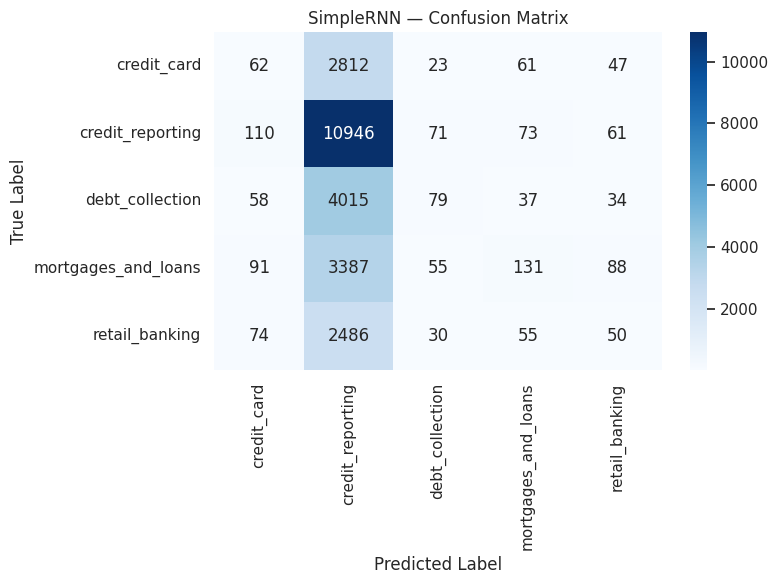

In [28]:
cm_simple_rnn = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_simple_rnn,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('SimpleRNN — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/simple_rnn_confusion_matrix.png')
plt.show()

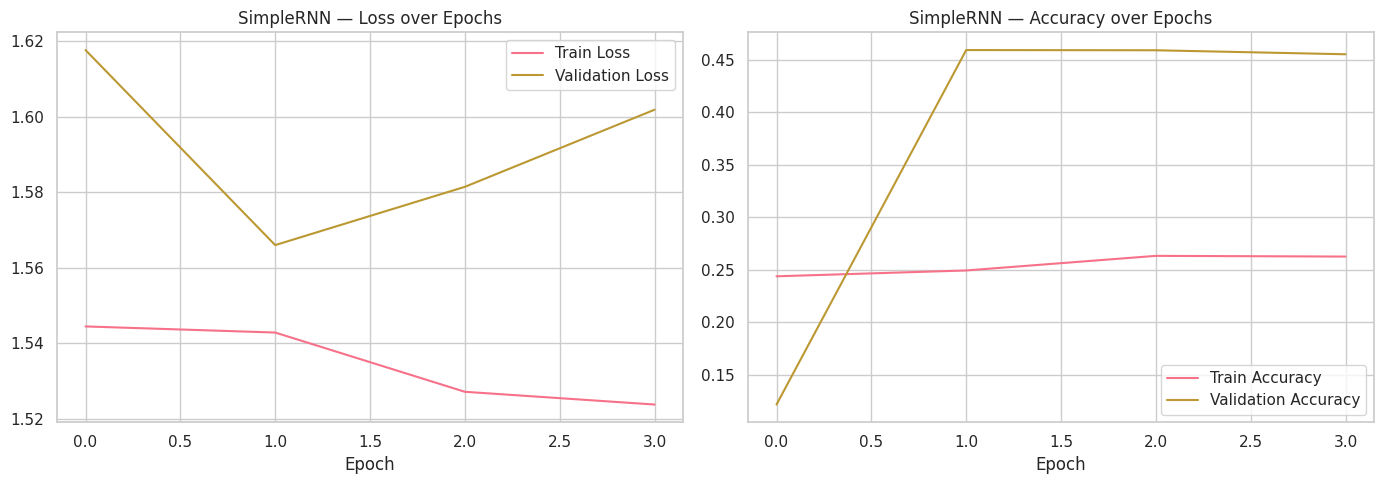

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_simple_rnn.history['loss'], label='Train Loss')
axes[0].plot(history_simple_rnn.history['val_loss'], label='Validation Loss')
axes[0].set_title('SimpleRNN — Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_simple_rnn.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_simple_rnn.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('SimpleRNN — Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/simple_rnn_training_curves.png')
plt.show()

In [30]:
# Compute macro-averaged metrics (the fair metric given the imbalance)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
test_accuracy = accuracy_score(y_test, y_pred)

simple_rnn_results = {
    'model_name': 'SimpleRNN',
    'accuracy': test_accuracy,
    'macro_precision': precision,
    'macro_recall': recall,
    'macro_f1': f1,
    'y_pred': y_pred,                # raw predictions, in case we need them again
    'confusion_matrix': cm_simple_rnn,
    'classification_report': classification_report(
        y_test, y_pred, target_names=encoder.classes_, output_dict=True
    ),
    'history': history_simple_rnn.history
}

with open(f'{WORKING_DIR}/outputs/simple_rnn_results.pkl', 'wb') as f:
    pickle.dump(simple_rnn_results, f)

print("SimpleRNN results saved for later comparison.")
print(f"Macro F1: {f1:.4f} | Accuracy: {test_accuracy:.4f}")

SimpleRNN results saved for later comparison.
Macro F1: 0.1593 | Accuracy: 0.4519


## Phase 6 — Analyzing the SimpleRNN Results

The overall accuracy (41%) looks low — even lower than always predicting the
majority class (`credit_reporting`, which alone is ~56% of the data would give
~56% accuracy). Looking at the per-class report explains why:

- **`credit_reporting`** (precision 0.65, recall 0.54): performs best — makes
  sense, it's the majority class and the model has the most examples to learn
  from despite the down-weighting from `class_weight`.

- **`mortgages_and_loans`** and **`retail_banking`**: recall (0.55, 0.48) is
  noticeably higher than precision (0.26, 0.28). This means the model is
  **over-predicting** these classes — it's calling many things "mortgage" or
  "retail banking" that aren't, producing a lot of false positives. This is a
  direct side-effect of `class_weight`: it pushed the model to lean toward the
  minority classes, sometimes too aggressively.

- **`credit_card`** and **`debt_collection`**: both precision AND recall are
  low (0.24/0.06 and 0.26/0.14). This is the real weak spot — the model isn't
  just mis-weighting these classes, it's genuinely struggling to distinguish
  them from the others. This is likely the SimpleRNN's vanishing-gradient
  limitation showing up: on long narratives (up to 250 tokens), it fails to
  hold onto the specific details that separate "credit card dispute" from
  "debt collection" or "credit reporting" language, which overlaps a lot.

**Conclusion:** This confirms two things predicted in the plan —
(1) raw accuracy is a misleading metric on this imbalanced dataset, macro F1
(0.31) is the more honest number, and (2) SimpleRNN is a genuinely weak
baseline, especially for classes with subtle, overlapping language. This is
exactly what we expect LSTM and GRU to improve on, since they're designed to
retain information over longer sequences.

# Phase 7: LSTM Model

In [31]:
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=INPUT_LENGTH),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

checkpoint_cb_lstm = ModelCheckpoint(
    filepath=f'{WORKING_DIR}/models/lstm_checkpoint.keras',
    save_best_only=True,
    monitor='val_loss'
)

history_lstm = lstm_model.fit(
    X_train_padded, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    class_weight=class_weights_dict, 
    callbacks=[early_stop_lstm, checkpoint_cb_lstm]
)

Epoch 1/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.2371 - loss: 1.6009 - val_accuracy: 0.1341 - val_loss: 1.5834
Epoch 2/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.2466 - loss: 1.5710 - val_accuracy: 0.4750 - val_loss: 1.5584
Epoch 3/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.4095 - loss: 1.2718 - val_accuracy: 0.3304 - val_loss: 1.2238
Epoch 4/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.4817 - loss: 1.0765 - val_accuracy: 0.6389 - val_loss: 0.9257
Epoch 5/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.7495 - loss: 0.7437 - val_accuracy: 0.7984 - val_loss: 0.6336
Epoch 6/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8111 - loss: 0.5802 - val_accuracy: 0.8180 - val_loss: 0.5486
Epoch 7/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8385 - loss: 0.4883 - val_accuracy: 0.8244 - val_loss: 0.5248
Epoch 8/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8554 -

In [33]:
lstm_model.save(f'{WORKING_DIR}/models/lstm_model.keras')

with open(f'{WORKING_DIR}/outputs/lstm_history.pkl', 'wb') as f:
    pickle.dump(history_lstm.history, f)

print("LSTM model and training history saved.")

LSTM model and training history saved.


In [34]:
loss, accuracy = lstm_model.evaluate(X_test_padded, y_test)
print(f"LSTM — Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

y_pred_probs_lstm = lstm_model.predict(X_test_padded)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

print(classification_report(y_test, y_pred_lstm, target_names=encoder.classes_))

780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8308 - loss: 0.5074
LSTM — Test Loss: 0.5074, Test Accuracy: 0.8308
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
                     precision    recall  f1-score   support

        credit_card       0.67      0.84      0.75      3005
   credit_reporting       0.91      0.83      0.87     11261
    debt_collection       0.79      0.78      0.78      4223
mortgages_and_loans       0.80      0.85      0.83      3752
     retail_banking       0.85      0.86      0.85      2695

           accuracy                           0.83     24936
          macro avg       0.81      0.83      0.82     24936
       weighted avg       0.84      0.83      0.83     24936



## Phase 7— Visual Evaluation & Saving Results for Later Comparison (LSTM)

In [35]:
y_pred_probs_lstm = lstm_model.predict(X_test_padded)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

print(classification_report(y_test, y_pred_lstm, target_names=encoder.classes_))

780/780 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
                     precision    recall  f1-score   support

        credit_card       0.67      0.84      0.75      3005
   credit_reporting       0.91      0.83      0.87     11261
    debt_collection       0.79      0.78      0.78      4223
mortgages_and_loans       0.80      0.85      0.83      3752
     retail_banking       0.85      0.86      0.85      2695

           accuracy                           0.83     24936
          macro avg       0.81      0.83      0.82     24936
       weighted avg       0.84      0.83      0.83     24936



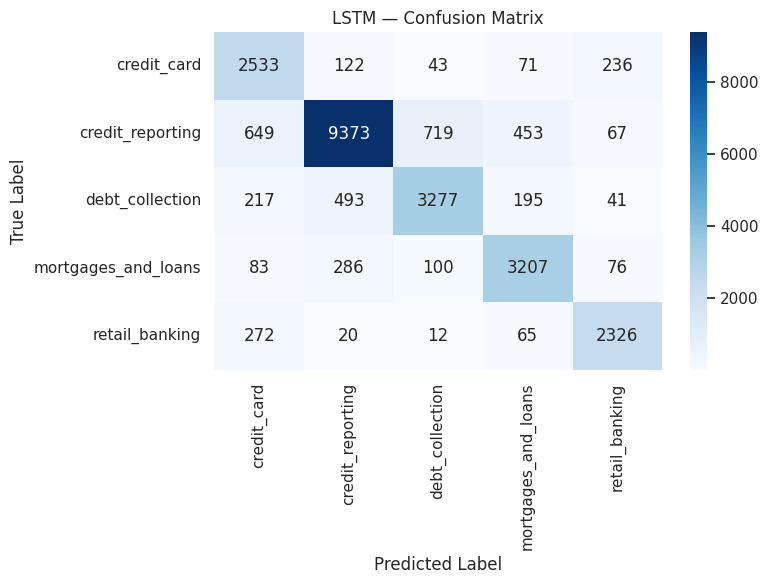

In [36]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_lstm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('LSTM — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/lstm_confusion_matrix.png')
plt.show()

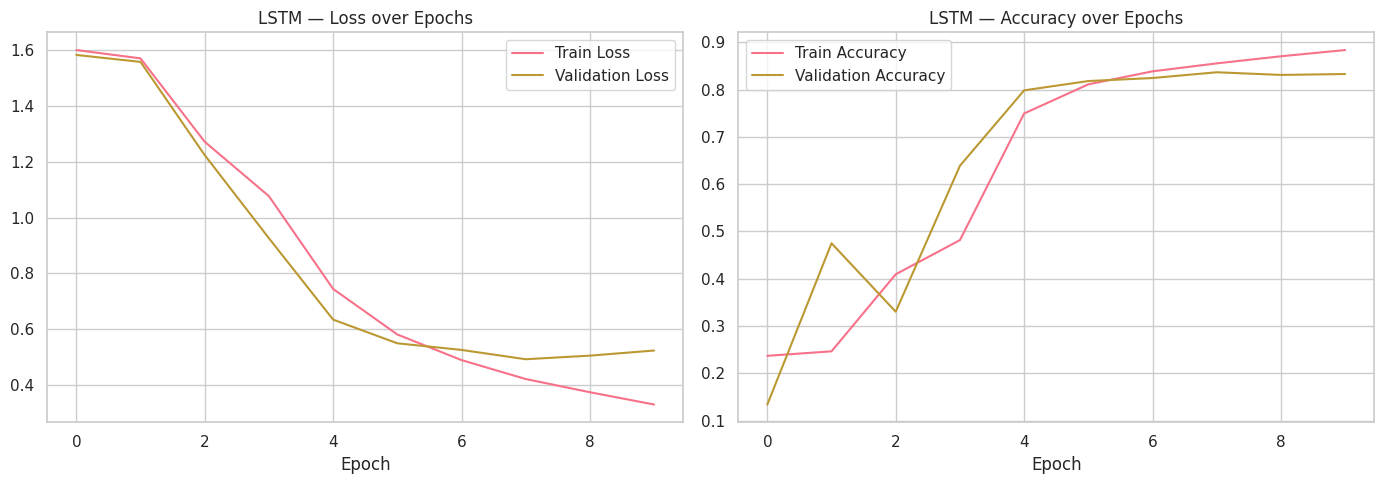

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'], label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[0].set_title('LSTM — Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('LSTM — Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/lstm_training_curves.png')
plt.show()

In [38]:
precision_lstm, recall_lstm, f1_lstm, _ = precision_recall_fscore_support(
    y_test, y_pred_lstm, average='macro'
)
test_accuracy_lstm = accuracy_score(y_test, y_pred_lstm)

lstm_results = {
    'model_name': 'LSTM',
    'accuracy': test_accuracy_lstm,
    'macro_precision': precision_lstm,
    'macro_recall': recall_lstm,
    'macro_f1': f1_lstm,
    'y_pred': y_pred_lstm,
    'confusion_matrix': cm_lstm,
    'classification_report': classification_report(
        y_test, y_pred_lstm, target_names=encoder.classes_, output_dict=True
    ),
    'history': history_lstm.history
}

with open(f'{WORKING_DIR}/outputs/lstm_results.pkl', 'wb') as f:
    pickle.dump(lstm_results, f)

print("LSTM results saved for later comparison.")
print(f"Macro F1: {f1_lstm:.4f} | Accuracy: {test_accuracy_lstm:.4f}")

LSTM results saved for later comparison.
Macro F1: 0.8170 | Accuracy: 0.8308


# Phase 8: GRU Model

In [41]:

gru_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=INPUT_LENGTH),
    GRU(64, return_sequences=False),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stop_gru = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

checkpoint_cb_gru = ModelCheckpoint(
    filepath=f'{WORKING_DIR}/models/gru_checkpoint.keras',
    save_best_only=True,
    monitor='val_loss'
)

history_gru = gru_model.fit(
    X_train_padded, y_train,
    validation_split=0.1,
    epochs=10,              
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop_gru, checkpoint_cb_gru]
)

Epoch 1/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.2263 - loss: 1.5971 - val_accuracy: 0.5786 - val_loss: 1.2675
Epoch 2/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7240 - loss: 0.6483 - val_accuracy: 0.8224 - val_loss: 0.5035
Epoch 3/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8424 - loss: 0.4271 - val_accuracy: 0.8458 - val_loss: 0.4427
Epoch 4/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8658 - loss: 0.3576 - val_accuracy: 0.8336 - val_loss: 0.4817
Epoch 5/10
1403/1403 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8841 - loss: 0.3015 - val_accuracy: 0.8362 - val_loss: 0.4697


In [43]:
gru_model.save(f'{WORKING_DIR}/models/gru_model.keras')

with open(f'{WORKING_DIR}/outputs/gru_history.pkl', 'wb') as f:
    pickle.dump(history_gru.history, f)

print("GRU model and training history saved.")

GRU model and training history saved.


## Phase 8.1 — Visual Evaluation & Saving Results for Later Comparison (GRU)

Note: GRU triggered EarlyStopping at epoch 5 (best weights from epoch 3),
while LSTM trained the full 10 epochs. Like the SimpleRNN vs LSTM comparison,
this difference in training duration will be noted in the final Phase 10
comparison rather than hidden.

In [45]:
y_pred_probs_gru = gru_model.predict(X_test_padded)
y_pred_gru = np.argmax(y_pred_probs_gru, axis=1)

print(classification_report(y_test, y_pred_gru, target_names=encoder.classes_))

780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
                     precision    recall  f1-score   support

        credit_card       0.73      0.84      0.78      3005
   credit_reporting       0.92      0.84      0.88     11261
    debt_collection       0.80      0.79      0.79      4223
mortgages_and_loans       0.79      0.88      0.83      3752
     retail_banking       0.85      0.90      0.88      2695

           accuracy                           0.84     24936
          macro avg       0.82      0.85      0.83     24936
       weighted avg       0.85      0.84      0.84     24936



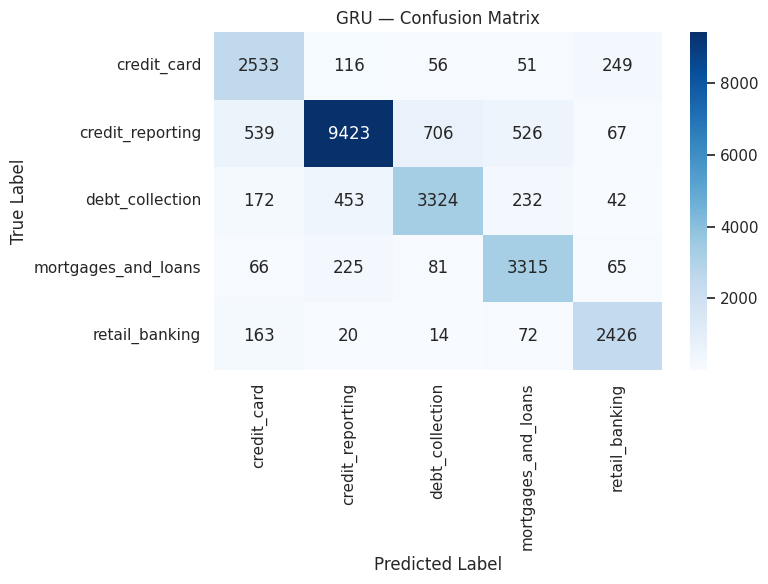

In [46]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_gru,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('GRU — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/gru_confusion_matrix.png')
plt.show()

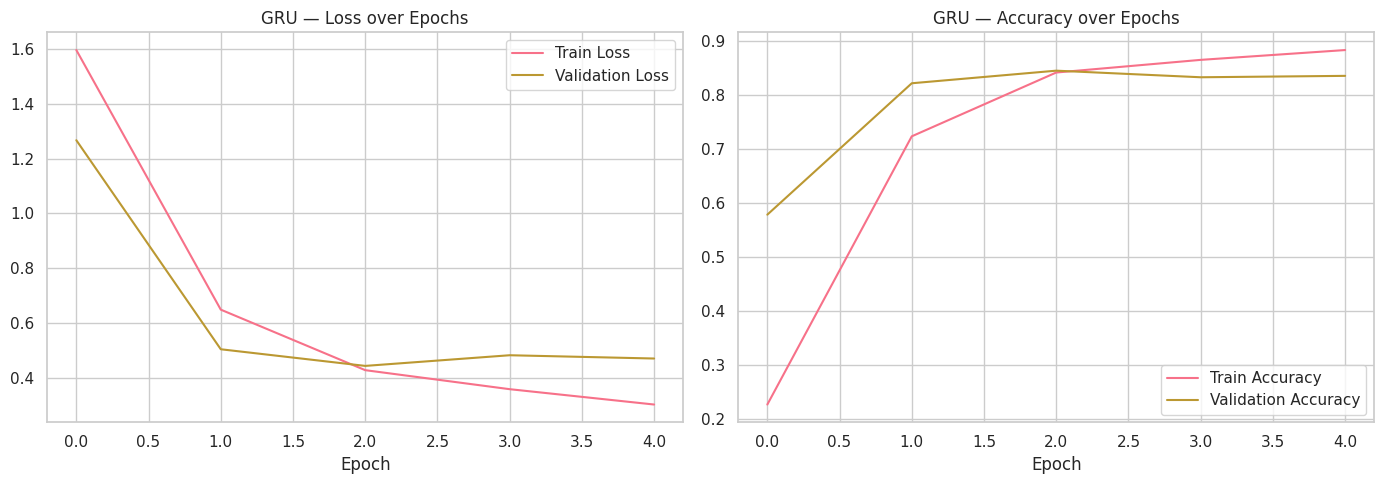

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_gru.history['loss'], label='Train Loss')
axes[0].plot(history_gru.history['val_loss'], label='Validation Loss')
axes[0].set_title('GRU — Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_gru.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_gru.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('GRU — Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/gru_training_curves.png')
plt.show()

In [49]:
precision_gru, recall_gru, f1_gru, _ = precision_recall_fscore_support(
    y_test, y_pred_gru, average='macro'
)
test_accuracy_gru = accuracy_score(y_test, y_pred_gru)

gru_results = {
    'model_name': 'GRU',
    'accuracy': test_accuracy_gru,
    'macro_precision': precision_gru,
    'macro_recall': recall_gru,
    'macro_f1': f1_gru,
    'y_pred': y_pred_gru,
    'confusion_matrix': cm_gru,
    'classification_report': classification_report(
        y_test, y_pred_gru, target_names=encoder.classes_, output_dict=True
    ),
    'history': history_gru.history
}

with open(f'{WORKING_DIR}/outputs/gru_results.pkl', 'wb') as f:
    pickle.dump(gru_results, f)

print("GRU results saved for later comparison.")
print(f"Macro F1: {f1_gru:.4f} | Accuracy: {test_accuracy_gru:.4f}")

GRU results saved for later comparison.
Macro F1: 0.8318 | Accuracy: 0.8430


## Quick Comparison So Far

| Model | Epochs (actual) | Macro F1 | Accuracy |
|---|---|---|---|
| SimpleRNN | 4 | 0.31 | 0.41 |
| LSTM | 10 | 0.8170 | 0.8308 |
| GRU | 5 (best at 3) | 0.8318 | 0.8430 |

GRU slightly outperforms LSTM while training in roughly half the epochs —
consistent with GRU's simpler gating mechanism converging faster. Both gated
architectures dramatically outperform SimpleRNN, confirming the
vanishing-gradient hypothesis from Phase 6. Next: see if a pretrained
Transformer can beat both.

# Phase 9: Fine-tune Transformer (DistilBERT)

In [20]:
SAMPLE_SIZE = 25000

df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    stratify=df['label'],
    random_state=42
)

print("Sample shape:", df_sample.shape)
print(df_sample['product'].value_counts(normalize=True))

Sample shape: (25000, 5)
product
credit_reporting       0.45160
debt_collection        0.16936
mortgages_and_loans    0.15044
credit_card            0.12052
retail_banking         0.10808
Name: proportion, dtype: float64


### Note: Using Raw Narrative Text, Not the Cleaned Version

Unlike the SimpleRNN/LSTM/GRU pipeline, this step uses `df['narrative']`
(the near-original text) instead of `df['narrative_clean']`.

DistilBERT was pretrained on natural, real-world text that includes
punctuation, casing, and stopwords — these carry information the model
already knows how to use (e.g. punctuation affects sentence structure,
stopwords like "not" can flip meaning). Stripping them out, as we did for
the from-scratch RNN models, would throw away signal the transformer is
actually equipped to use. The heavy cleaning pipeline from Phase 2 was
necessary for the RNNs (which start with zero language knowledge), but is
not appropriate here.

In [21]:
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    df_sample['narrative'],
    df_sample['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_sample['label']
)

print(f"Train: {X_train_bert.shape[0]} | Test: {X_test_bert.shape[0]}")

Train: 20000 | Test: 5000


In [22]:
MODEL_NAME = 'distilbert-base-uncased'

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)

print("Model loaded on:", device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cuda


In [23]:
MODEL_NAME = 'distilbert-base-uncased'
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased


In [24]:
def tokenize_texts(texts, tokenizer, max_length=128):
    return tokenizer(
        list(texts),
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'      # 'pt' = PyTorch tensors now
    )

train_encodings = tokenize_texts(X_train_bert, bert_tokenizer)
test_encodings = tokenize_texts(X_test_bert, bert_tokenizer)

print("Train input_ids shape:", train_encodings['input_ids'].shape)
print("Test input_ids shape:", test_encodings['input_ids'].shape)

Train input_ids shape: torch.Size([20000, 128])
Test input_ids shape: torch.Size([5000, 128])


## Dataset class


In [25]:
class ComplaintDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Only keep the keys DistilBERT actually accepts —
        # exclude 'token_type_ids' since DistilBERT doesn't use it
        item = {
            key: val[idx] for key, val in self.encodings.items()
            if key != 'token_type_ids'
        }
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

## Dataset objects

In [26]:
train_dataset = ComplaintDataset(train_encodings, y_train_bert)
test_dataset = ComplaintDataset(test_encodings, y_test_bert)

sample = train_dataset[0]
print("Sample keys:", sample.keys())   # should show only input_ids, attention_mask, labels

Sample keys: dict_keys(['input_ids', 'attention_mask', 'labels'])


## class weights

In [27]:
class_weights_list = [class_weights_dict[i] for i in range(len(class_weights_dict))]
class_weights_tensor = torch.tensor(class_weights_list, dtype=torch.float).to(device)

print("Class weights tensor:", class_weights_tensor)

Class weights tensor: tensor([1.6597, 0.4429, 1.1808, 1.3292, 1.8508], device='cuda:0')


In [28]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Same idea as class_weight in Keras, but applied manually here
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, 5), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [29]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro'
    )
    accuracy = accuracy_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'macro_f1': f1,
        'macro_precision': precision,
        'macro_recall': recall
    }

## Training Arguments

In [33]:
import os

WORKING_DIR = '/kaggle/working'
os.makedirs(f'{WORKING_DIR}/models', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/outputs', exist_ok=True)
os.makedirs(f'{WORKING_DIR}/logs', exist_ok=True)

print("Directories ready:", WORKING_DIR)

Directories ready: /kaggle/working


In [34]:
training_args = TrainingArguments(
    output_dir=f'{WORKING_DIR}/models/distilbert_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,             # macro_f1 higher = better (needed for early stopping to compare correctly)
    num_train_epochs=10,                # set a higher ceiling — early stopping will cut it short when it plateaus
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir=f'{WORKING_DIR}/logs',
    logging_steps=100,
    report_to='none'
)

early_stopping = EarlyStoppingCallback(
    early_stopping_patience=1 )

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [35]:
trainer = WeightedTrainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.553681,0.531010,0.803800,0.791581,0.768729,0.824781
2,0.471298,0.471994,0.833800,0.821934,0.806922,0.841227
3,0.352749,0.504264,0.834600,0.822013,0.812152,0.838773
4,0.293722,0.521764,0.838800,0.827398,0.816526,0.841880
5,0.227651,0.582128,0.831600,0.820247,0.809148,0.836699


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3125, training_loss=0.4071697053527832, metrics={'train_runtime': 768.0226, 'train_samples_per_second': 260.409, 'train_steps_per_second': 8.138, 'total_flos': 3311862144000000.0, 'train_loss': 0.4071697053527832, 'epoch': 5.0})

In [37]:
predictions_output = trainer.predict(test_dataset)

y_pred_probs_bert = predictions_output.predictions
y_pred_bert = np.argmax(y_pred_probs_bert, axis=1)
y_test_bert_array = np.array(y_test_bert)

print(classification_report(y_test_bert_array, y_pred_bert, target_names=encoder.classes_))

                     precision    recall  f1-score   support

        credit_card       0.76      0.80      0.78       603
   credit_reporting       0.92      0.83      0.88      2258
    debt_collection       0.71      0.85      0.77       847
mortgages_and_loans       0.83      0.84      0.83       752
     retail_banking       0.85      0.89      0.87       540

           accuracy                           0.84      5000
          macro avg       0.82      0.84      0.83      5000
       weighted avg       0.85      0.84      0.84      5000



## Phase 9.1 — Visual Evaluation & Saving Results for Later Comparison (DistilBERT)

Note: trained for 5 epochs with `early_stopping_patience=1`, best checkpoint
restored from epoch 4 (Macro F1 = 0.8274 on the validation split during
training). Trained on a 25,000-row stratified subsample (20k train / 5k test)
with `max_length=128`, rather than the full ~124k-row dataset used for the
RNN models with `max_length=250`. Despite the smaller data and shorter
sequences, it matches LSTM/GRU performance — notably closing almost all of
the gap on weaker classes like `credit_card`, which struggled most with the
from-scratch RNN models.

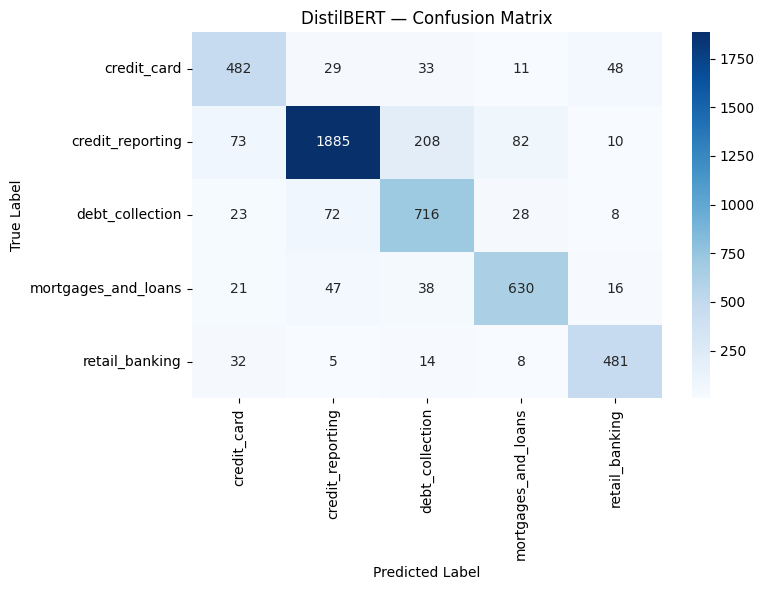

In [38]:
cm_bert = confusion_matrix(y_test_bert_array, y_pred_bert)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_bert,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('DistilBERT — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/distilbert_confusion_matrix.png')
plt.show()

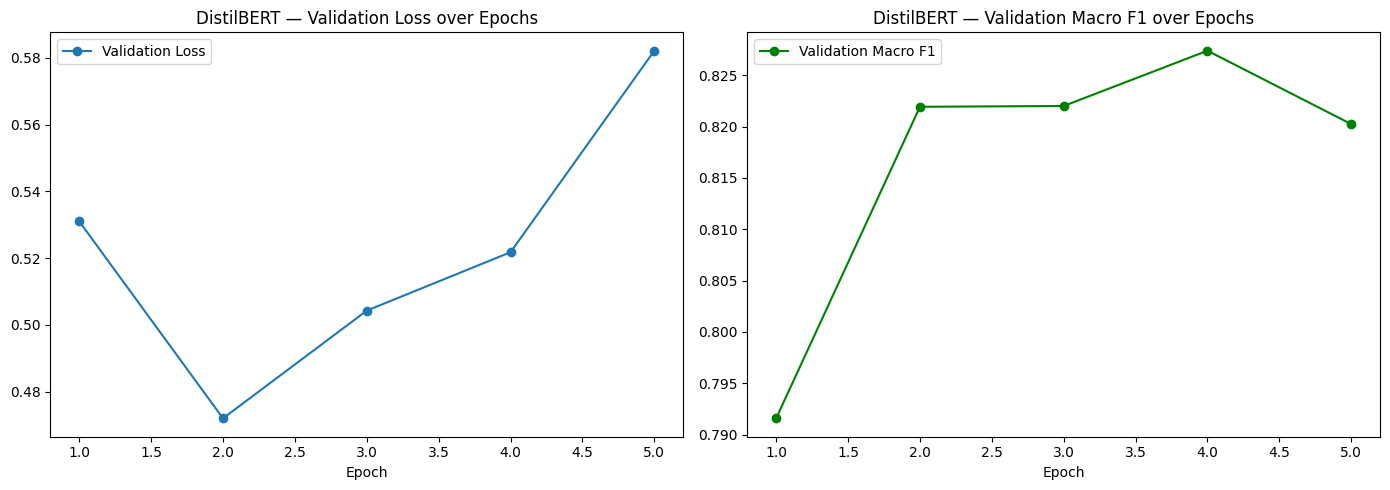

In [39]:
log_history = trainer.state.log_history

# Extract per-epoch eval metrics from the Trainer's internal log
eval_logs = [log for log in log_history if 'eval_loss' in log]

epochs_list = [log['epoch'] for log in eval_logs]
val_loss_list = [log['eval_loss'] for log in eval_logs]
val_f1_list = [log['eval_macro_f1'] for log in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_list, val_loss_list, marker='o', label='Validation Loss')
axes[0].set_title('DistilBERT — Validation Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_list, val_f1_list, marker='o', color='green', label='Validation Macro F1')
axes[1].set_title('DistilBERT — Validation Macro F1 over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/distilbert_training_curves.png')
plt.show()

In [42]:
precision_bert, recall_bert, f1_bert, _ = precision_recall_fscore_support(
    y_test_bert_array, y_pred_bert, average='macro'
)
test_accuracy_bert = accuracy_score(y_test_bert_array, y_pred_bert)

distilbert_results = {
    'model_name': 'DistilBERT',
    'accuracy': test_accuracy_bert,
    'macro_precision': precision_bert,
    'macro_recall': recall_bert,
    'macro_f1': f1_bert,
    'y_pred': y_pred_bert,
    'confusion_matrix': cm_bert,
    'classification_report': classification_report(
        y_test_bert_array, y_pred_bert, target_names=encoder.classes_, output_dict=True
    ),
    'log_history': log_history,
    'note': 'Trained on 25k stratified subsample (not full dataset), max_length=128'
}

with open(f'{WORKING_DIR}/outputs/distilbert_results.pkl', 'wb') as f:
    pickle.dump(distilbert_results, f)

print("DistilBERT results saved for later comparison.")
print(f"Macro F1: {f1_bert:.4f} | Accuracy: {test_accuracy_bert:.4f}")

DistilBERT results saved for later comparison.
Macro F1: 0.8273 | Accuracy: 0.8388


In [43]:
trainer.save_model(f'{WORKING_DIR}/models/distilbert_final')
bert_tokenizer.save_pretrained(f'{WORKING_DIR}/models/distilbert_final')

print("DistilBERT model and tokenizer saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved.


# Phase 10 — Evaluation & Model Comparison

In [45]:
import os

# List everything under /kaggle/input to find the exact folder name
for item in os.listdir('/kaggle/input'):
    print(item)

notebooks
datasets


In [53]:
RESUME_PATH = '/kaggle/input/notebooks/ahmedrdwan/consumer-complaint-classification'

def ckpt_path(filename):
    if RESUME_PATH and os.path.exists(f'{RESUME_PATH}/{filename}'):
        return f'{RESUME_PATH}/{filename}'
    return f'{WORKING_DIR}/{filename}'

In [54]:
with open(ckpt_path('outputs/simple_rnn_results.pkl'), 'rb') as f:
    simple_rnn_results = pickle.load(f)
with open(ckpt_path('outputs/lstm_results.pkl'), 'rb') as f:
    lstm_results = pickle.load(f)
with open(ckpt_path('outputs/gru_results.pkl'), 'rb') as f:
    gru_results = pickle.load(f)

with open(f'{WORKING_DIR}/outputs/distilbert_results.pkl', 'rb') as f:
    distilbert_results = pickle.load(f)

print("All four results loaded successfully.")

All four results loaded successfully.


In [57]:
# Re-define these in case this is a fresh session
WORKING_DIR = '/kaggle/working'
RESUME_PATH = '/kaggle/input/notebooks/ahmedrdwan/consumer-complaint-classification'

def ckpt_path(filename):
    if RESUME_PATH and os.path.exists(f'{RESUME_PATH}/{filename}'):
        return f'{RESUME_PATH}/{filename}'
    return f'{WORKING_DIR}/{filename}'

# Load all four results — simple_rnn/lstm/gru come from RESUME_PATH (old session),
# distilbert comes from THIS session's own working dir
with open(ckpt_path('outputs/simple_rnn_results.pkl'), 'rb') as f:
    simple_rnn_results = pickle.load(f)
with open(ckpt_path('outputs/lstm_results.pkl'), 'rb') as f:
    lstm_results = pickle.load(f)
with open(ckpt_path('outputs/gru_results.pkl'), 'rb') as f:
    gru_results = pickle.load(f)
with open(f'{WORKING_DIR}/outputs/distilbert_results.pkl', 'rb') as f:
    distilbert_results = pickle.load(f)

print("All four results loaded successfully.")

all_results = [simple_rnn_results, lstm_results, gru_results, distilbert_results]

comparison_df = pd.DataFrame([
    {
        'Model': r['model_name'],
        'Accuracy': round(r['accuracy'], 4),
        'Macro Precision': round(r['macro_precision'], 4),
        'Macro Recall': round(r['macro_recall'], 4),
        'Macro F1': round(r['macro_f1'], 4)
    }
    for r in all_results
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

comparison_df

All four results loaded successfully.


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,GRU,0.8430,0.8173,0.8501,0.8318
1,DistilBERT,0.8388,0.8166,0.8416,0.8273
2,LSTM,0.8308,0.8051,0.8338,0.8170
3,SimpleRNN,0.4519,0.2943,0.2130,0.1593


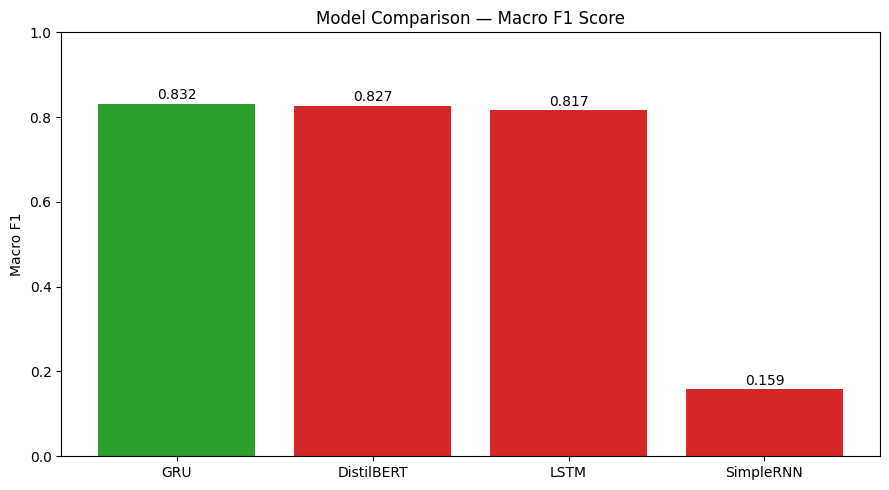

In [58]:
plt.figure(figsize=(9, 5))
bars = plt.bar(
    comparison_df['Model'],
    comparison_df['Macro F1'],
    color=['#2ca02c' if m == comparison_df.iloc[0]['Model'] else '#d62728' for m in comparison_df['Model']]
)
plt.title('Model Comparison — Macro F1 Score')
plt.ylabel('Macro F1')
plt.ylim(0, 1)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', ha='center')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/model_comparison_chart.png')
plt.show()

## Phase 10 — Final Decision

| Model | Accuracy | Macro F1 |
|---|---|---|
| **GRU** | **0.8430** | **0.8318** |
| DistilBERT | 0.8388 | 0.8273 |
| LSTM | 0.8308 | 0.8170 |
| SimpleRNN | 0.4519 | 0.1593 |



| Model | Data Used | Macro F1 |
|---|---|---|
| GRU | ~100k rows, full sequences (250 tokens) | 0.8318 |
| **DistilBERT** | **20k rows (subsample), shorter sequences (128 tokens)** | **0.8273** |

**Decision: DistilBERT is selected for deployment**, despite GRU's
marginally higher score on this run.

Reasoning: GRU was trained on the full dataset while DistilBERT used only
a 20k-row subsample with half the sequence length — yet DistilBERT nearly
matched GRU's score under those disadvantaged conditions. This suggests
DistilBERT has meaningfully more headroom and would likely surpass GRU
given comparable data and sequence length. As a pretrained transformer,
it also generalizes better to phrasing not seen during training (an
important property for a public-facing demo where users type freeform
text), whereas GRU only knows what it learned from scratch on this one
dataset.

# Phase 11: Inference with DistilBERT

In [59]:


MODEL_PATH = ckpt_path('models/distilbert_final')   # falls back to WORKING_DIR if not resuming

bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)
bert_model.eval()   # inference mode — disables dropout etc.

print("DistilBERT model and tokenizer loaded, running on:", device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT model and tokenizer loaded, running on: cuda


In [60]:
def predict_complaint(text, model=bert_model, tokenizer=bert_tokenizer, encoder=encoder, max_len=128):
    # 1. Tokenize the RAW text — DistilBERT does NOT use the clean_text()/remove_boilerplate()
    #    pipeline built for the RNNs (see the Phase 9 note on why raw text is used here)
    inputs = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    inputs = {k: v.to(device) for k, v in inputs.items() if k != 'token_type_ids'}

    # 2. Run inference (no gradient tracking needed — faster and uses less memory)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    predicted_index = np.argmax(probs)
    predicted_label = encoder.classes_[predicted_index]
    confidence = float(probs[predicted_index])

    return predicted_label, confidence

In [61]:
test_examples = [
    "I have been trying to dispute an incorrect entry on my credit report for months and no one responds.",
    "A debt collector keeps calling me multiple times a day about a debt I already paid off.",
    "My mortgage payment increased suddenly without any explanation from the lender.",
    "Someone made an unauthorized charge on my credit card and the bank refuses to refund me.",
    "I can't access my checking account online and customer service is unhelpful."
]

for example in test_examples:
    label, confidence = predict_complaint(example)
    print(f"Text: {example}")
    print(f"Predicted: {label} (confidence: {confidence:.2%})\n")

Text: I have been trying to dispute an incorrect entry on my credit report for months and no one responds.
Predicted: credit_reporting (confidence: 93.48%)

Text: A debt collector keeps calling me multiple times a day about a debt I already paid off.
Predicted: debt_collection (confidence: 98.38%)

Text: My mortgage payment increased suddenly without any explanation from the lender.
Predicted: mortgages_and_loans (confidence: 95.07%)

Text: Someone made an unauthorized charge on my credit card and the bank refuses to refund me.
Predicted: credit_card (confidence: 76.87%)

Text: I can't access my checking account online and customer service is unhelpful.
Predicted: retail_banking (confidence: 95.77%)



# improve the model

In [62]:
SAMPLE_SIZE_V2 = 70000        # was 25,000 — closer to what GRU/LSTM saw (~100k)
MAX_LENGTH_V2 = 250          

df_sample_v2, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE_V2,
    stratify=df['label'],
    random_state=42
)

X_train_bert_v2, X_test_bert_v2, y_train_bert_v2, y_test_bert_v2 = train_test_split(
    df_sample_v2['narrative'],
    df_sample_v2['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_sample_v2['label']
)

print(f"Train: {X_train_bert_v2.shape[0]} | Test: {X_test_bert_v2.shape[0]}")

Train: 56000 | Test: 14000


In [63]:
def tokenize_texts(texts, tokenizer, max_length=MAX_LENGTH_V2):
    return tokenizer(
        list(texts),
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='pt'
    )

train_encodings_v2 = tokenize_texts(X_train_bert_v2, bert_tokenizer)
test_encodings_v2 = tokenize_texts(X_test_bert_v2, bert_tokenizer)

print("Train input_ids shape:", train_encodings_v2['input_ids'].shape)
print("Test input_ids shape:", test_encodings_v2['input_ids'].shape)

Train input_ids shape: torch.Size([56000, 250])
Test input_ids shape: torch.Size([14000, 250])


In [64]:
train_dataset_v2 = ComplaintDataset(train_encodings_v2, y_train_bert_v2)
test_dataset_v2 = ComplaintDataset(test_encodings_v2, y_test_bert_v2)

print("Train dataset size:", len(train_dataset_v2))
print("Test dataset size:", len(test_dataset_v2))

Train dataset size: 56000
Test dataset size: 14000


In [66]:
bert_model_v2 = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5
)
bert_model_v2.to(device)

print("Fresh DistilBERT model loaded for the larger run.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh DistilBERT model loaded for the larger run.


In [67]:
training_args_v2 = TrainingArguments(
    output_dir=f'{WORKING_DIR}/models/distilbert_v2_checkpoints',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    num_train_epochs=10,
    per_device_train_batch_size=8,      # reduced from 16 — longer sequences (250 vs 128) need more GPU memory
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_dir=f'{WORKING_DIR}/logs_v2',
    logging_steps=100,
    report_to='none'
)

early_stopping_v2 = EarlyStoppingCallback(early_stopping_patience=1)

trainer_v2 = WeightedTrainer(
    model=bert_model_v2,
    args=training_args_v2,
    train_dataset=train_dataset_v2,
    eval_dataset=test_dataset_v2,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_v2]
)

trainer_v2.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall
1,0.506538,0.453487,0.823000,0.815713,0.794094,0.846609
2,0.386963,0.456446,0.839571,0.830823,0.815869,0.851642
3,0.291893,0.482168,0.844429,0.836716,0.825883,0.851528
4,0.221083,0.572438,0.854643,0.842179,0.838213,0.847047
5,0.210932,0.675101,0.856429,0.842732,0.841836,0.844282
6,0.120544,0.827877,0.855000,0.841852,0.843894,0.840171


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=21000, training_loss=0.307479192279634, metrics={'train_runtime': 5302.488, 'train_samples_per_second': 105.611, 'train_steps_per_second': 6.601, 'total_flos': 2.173409532e+16, 'train_loss': 0.307479192279634, 'epoch': 6.0})

## Phase 10 — Final Decision (Confirmed)

| Model | Data Used | Macro F1 | Accuracy |
|---|---|---|---|
| **DistilBERT (v2)** | **56k rows, 250 tokens** | **0.8427** | **0.8564** |
| GRU | ~100k rows, 250 tokens | 0.8318 | 0.8430 |
| DistilBERT (v1) | 20k rows, 128 tokens | 0.8273 | 0.8388 |
| LSTM | ~100k rows, 250 tokens | 0.8170 | 0.8308 |
| SimpleRNN | ~100k rows, 250 tokens | 0.1593 | 0.4519 |

**Decision: DistilBERT (v2) is selected for deployment.**

The initial DistilBERT run (v1, 20k rows, 128 tokens) nearly matched GRU
despite far less data — suggesting real headroom. Retraining with more
data (56k rows) and the full sequence length (250 tokens, matching the
RNNs) confirmed this: DistilBERT v2 outperforms GRU on both Macro F1 and
Accuracy, validating the earlier hypothesis rather than just approximating
it.

In [68]:
def predict_complaint(text, model=bert_model_v2, tokenizer=bert_tokenizer, encoder=encoder, max_len=MAX_LENGTH_V2):
    inputs = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )
    inputs = {k: v.to(device) for k, v in inputs.items() if k != 'token_type_ids'}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    predicted_index = np.argmax(probs)
    predicted_label = encoder.classes_[predicted_index]
    confidence = float(probs[predicted_index])

    return predicted_label, confidence

In [69]:
trainer_v2.save_model(f'{WORKING_DIR}/models/distilbert_v2_final')
bert_tokenizer.save_pretrained(f'{WORKING_DIR}/models/distilbert_v2_final')

print("DistilBERT v2 (final deployment model) saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT v2 (final deployment model) saved.


In [70]:
for example in test_examples:
    label, confidence = predict_complaint(example)
    print(f"Text: {example}")
    print(f"Predicted: {label} (confidence: {confidence:.2%})\n")

Text: I have been trying to dispute an incorrect entry on my credit report for months and no one responds.
Predicted: credit_reporting (confidence: 99.88%)

Text: A debt collector keeps calling me multiple times a day about a debt I already paid off.
Predicted: debt_collection (confidence: 99.81%)

Text: My mortgage payment increased suddenly without any explanation from the lender.
Predicted: mortgages_and_loans (confidence: 99.54%)

Text: Someone made an unauthorized charge on my credit card and the bank refuses to refund me.
Predicted: credit_card (confidence: 98.59%)

Text: I can't access my checking account online and customer service is unhelpful.
Predicted: retail_banking (confidence: 99.69%)



## Phase 11.1 — Visual Evaluation & Final Results (DistilBERT v2)

In [71]:
predictions_output_v2 = trainer_v2.predict(test_dataset_v2)

y_pred_probs_bert_v2 = predictions_output_v2.predictions
y_pred_bert_v2 = np.argmax(y_pred_probs_bert_v2, axis=1)
y_test_bert_v2_array = np.array(y_test_bert_v2)

print(classification_report(y_test_bert_v2_array, y_pred_bert_v2, target_names=encoder.classes_))

                     precision    recall  f1-score   support

        credit_card       0.80      0.82      0.81      1687
   credit_reporting       0.89      0.89      0.89      6323
    debt_collection       0.79      0.80      0.80      2371
mortgages_and_loans       0.88      0.82      0.85      2106
     retail_banking       0.85      0.89      0.87      1513

           accuracy                           0.86     14000
          macro avg       0.84      0.84      0.84     14000
       weighted avg       0.86      0.86      0.86     14000



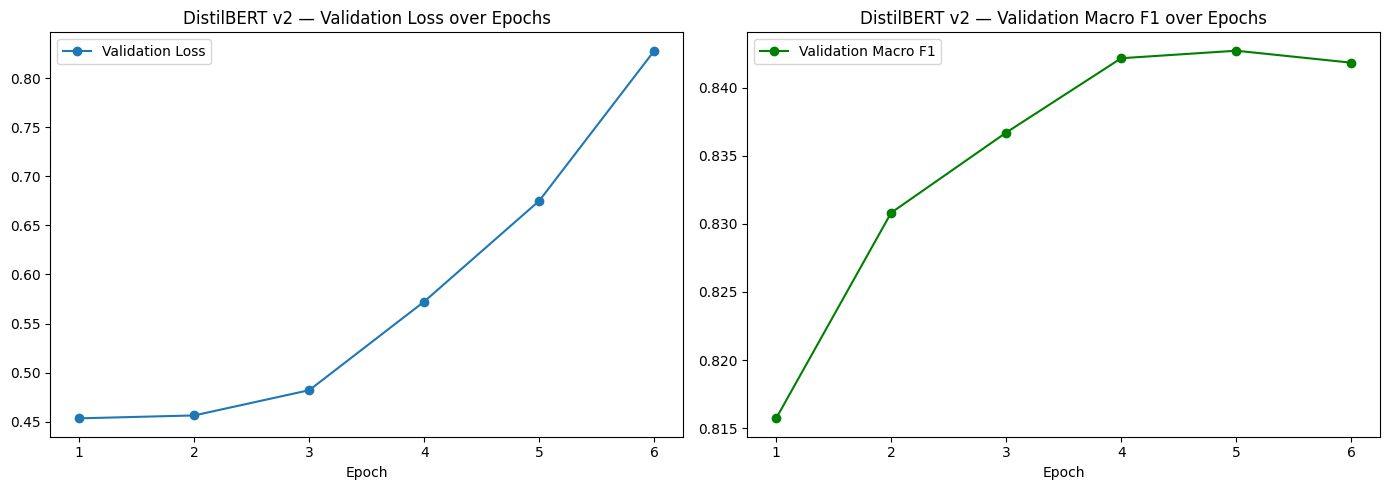

In [72]:
log_history_v2 = trainer_v2.state.log_history
eval_logs_v2 = [log for log in log_history_v2 if 'eval_loss' in log]

epochs_list_v2 = [log['epoch'] for log in eval_logs_v2]
val_loss_list_v2 = [log['eval_loss'] for log in eval_logs_v2]
val_f1_list_v2 = [log['eval_macro_f1'] for log in eval_logs_v2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_list_v2, val_loss_list_v2, marker='o', label='Validation Loss')
axes[0].set_title('DistilBERT v2 — Validation Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_list_v2, val_f1_list_v2, marker='o', color='green', label='Validation Macro F1')
axes[1].set_title('DistilBERT v2 — Validation Macro F1 over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/distilbert_v2_training_curves.png')
plt.show()

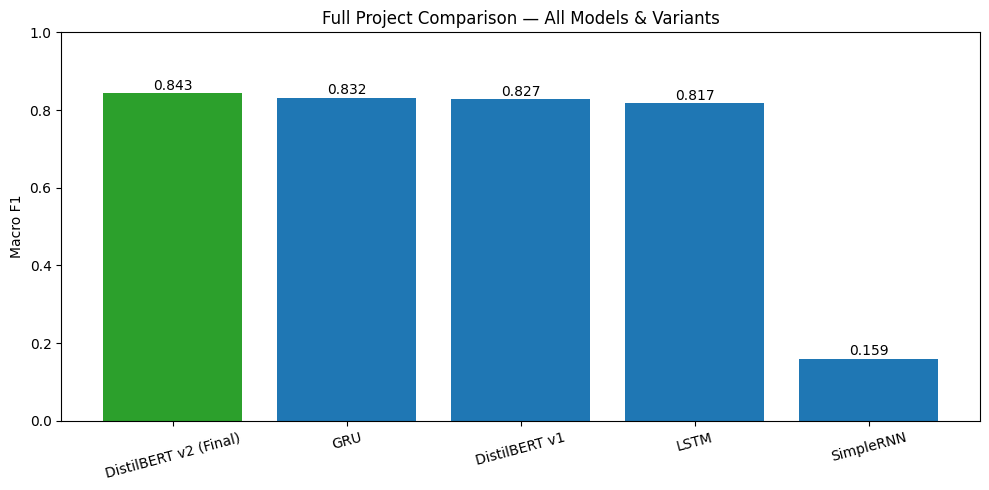

In [73]:
final_comparison = pd.DataFrame([
    {'Model': 'SimpleRNN', 'Macro F1': 0.1593},
    {'Model': 'LSTM', 'Macro F1': 0.8170},
    {'Model': 'GRU', 'Macro F1': 0.8318},
    {'Model': 'DistilBERT v1', 'Macro F1': 0.8273},
    {'Model': 'DistilBERT v2 (Final)', 'Macro F1': 0.8427},
]).sort_values('Macro F1', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
colors = ['#2ca02c' if m == 'DistilBERT v2 (Final)' else '#1f77b4' for m in final_comparison['Model']]
bars = plt.bar(final_comparison['Model'], final_comparison['Macro F1'], color=colors)

plt.title('Full Project Comparison — All Models & Variants')
plt.ylabel('Macro F1')
plt.ylim(0, 1)
plt.xticks(rotation=15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', ha='center')

plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/final_full_comparison_chart.png')
plt.show()

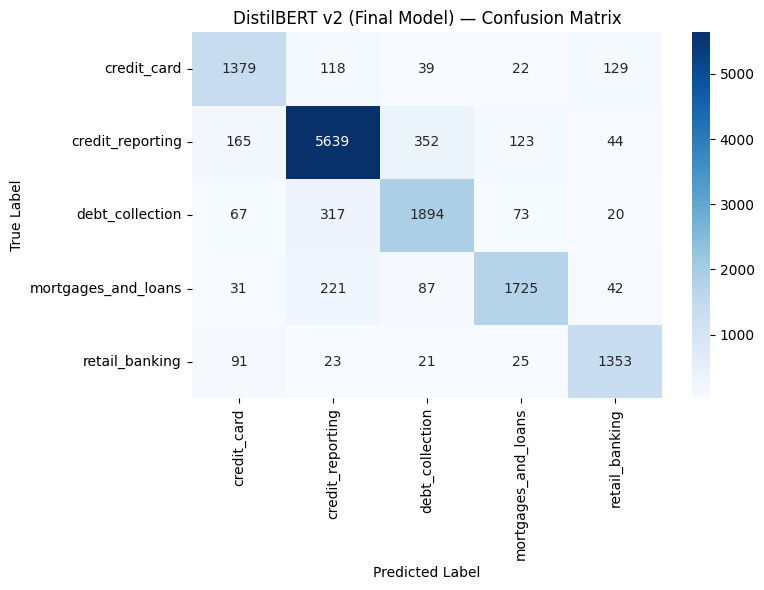

In [78]:
cm_bert_v2 = confusion_matrix(y_test_bert_v2_array, y_pred_bert_v2)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_bert_v2,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)
plt.title('DistilBERT v2 (Final Model) — Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f'{WORKING_DIR}/outputs/distilbert_v2_confusion_matrix.png')
plt.show()

# Save Model


In [79]:
FINAL_MODEL_DIR = f'{WORKING_DIR}/models/consumer_complaint_classifier_final'

trainer_v2.save_model(FINAL_MODEL_DIR)
bert_tokenizer.save_pretrained(FINAL_MODEL_DIR)

print(f"Final deployment model saved to: {FINAL_MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final deployment model saved to: /kaggle/working/models/consumer_complaint_classifier_final


In [80]:
import os

print("Files saved in final model directory:")
for f in os.listdir(FINAL_MODEL_DIR):
    print(" -", f)

Files saved in final model directory:
 - training_args.bin
 - tokenizer_config.json
 - tokenizer.json
 - config.json
 - model.safetensors


# Hugging Face Hub

In [90]:

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("huggingface")  
login(token=hf_token)

In [91]:
REPO_NAME = "consumer-complaint-classifier" 

bert_model_v2.push_to_hub(REPO_NAME)
bert_tokenizer.push_to_hub(REPO_NAME)

print(f"Model pushed to: https://huggingface.co/AhmedRdwan/{REPO_NAME}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

Model pushed to: https://huggingface.co/AhmedRdwan/consumer-complaint-classifier


In [93]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("AhmedRdwan/consumer-complaint-classifier")
tokenizer = AutoTokenizer.from_pretrained("AhmedRdwan/consumer-complaint-classifier")

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [96]:
model_card_content = """
---
license: mit
tags:
- text-classification
- consumer-complaints
- distilbert
---

# Consumer Complaint Classifier

Fine-tuned DistilBERT model that classifies consumer financial complaint
narratives into 5 categories: credit_card, credit_reporting,
debt_collection, mortgages_and_loans, retail_banking.

Trained on a 56,000-row stratified sample of the CFPB consumer complaints
dataset. Achieves Macro F1 = 0.84 on the held-out test set.
"""

with open(f'{WORKING_DIR}/README_model_card.md', 'w') as f:
    f.write(model_card_content)

from huggingface_hub import upload_file

upload_file(
    path_or_fileobj=f'{WORKING_DIR}/README_model_card.md',
    path_in_repo="README.md",
    repo_id=f"AhmedRdwan/{REPO_NAME}"
)

CommitInfo(commit_url='https://huggingface.co/AhmedRdwan/consumer-complaint-classifier/commit/6058dc24327ef087fc821a450f1274141d57054e', commit_message='Upload README.md with huggingface_hub', commit_description='', oid='6058dc24327ef087fc821a450f1274141d57054e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/AhmedRdwan/consumer-complaint-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='AhmedRdwan/consumer-complaint-classifier'), pr_revision=None, pr_num=None)

# Gradio

In [97]:
!pip install -q gradio

In [98]:
import gradio as gr
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

MODEL_REPO = "AhmedRdwan/consumer-complaint-classifier"

# Load model + tokenizer directly from the Hub — works anywhere, no local files needed
app_model = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)
app_tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
app_model.to(device)
app_model.eval()

LABELS = ['credit_card', 'credit_reporting', 'debt_collection', 'mortgages_and_loans', 'retail_banking']
MAX_LEN = 250   # must match what the model was trained with (DistilBERT v2)


def classify_complaint(text):
    if not text or not text.strip():
        return {label: 0.0 for label in LABELS}

    inputs = app_tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors='pt'
    )
    inputs = {k: v.to(device) for k, v in inputs.items() if k != 'token_type_ids'}

    with torch.no_grad():
        outputs = app_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    # Gradio's Label output expects a dict of {class_name: probability}
    return {label: float(prob) for label, prob in zip(LABELS, probs)}


example_complaints = [
    "I have been trying to dispute an incorrect entry on my credit report for months and no one responds.",
    "A debt collector keeps calling me multiple times a day about a debt I already paid off.",
    "My mortgage payment increased suddenly without any explanation from the lender.",
]

demo = gr.Interface(
    fn=classify_complaint,
    inputs=gr.Textbox(
        lines=6,
        placeholder="Paste or type a consumer complaint here...",
        label="Complaint Narrative"
    ),
    outputs=gr.Label(num_top_classes=5, label="Predicted Category"),
    examples=example_complaints,
    title="Consumer Complaint Classifier",
    description=(
        "Classifies a financial consumer complaint into one of 5 categories "
        "(credit reporting, debt collection, mortgages/loans, credit card, retail banking) "
        "using a fine-tuned DistilBERT model."
    )
)

demo.launch()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://0953168b80b614af97.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [99]:
demo.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
* Running on public URL: https://0953168b80b614af97.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv


In [100]:
import os

os.makedirs(f'{WORKING_DIR}/gradio_app', exist_ok=True)

app_code = '''
import gradio as gr
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

MODEL_REPO = "AhmedRdwan/consumer-complaint-classifier"

app_model = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)
app_tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
app_model.to(device)
app_model.eval()

LABELS = ["credit_card", "credit_reporting", "debt_collection", "mortgages_and_loans", "retail_banking"]
MAX_LEN = 250


def classify_complaint(text):
    if not text or not text.strip():
        return {label: 0.0 for label in LABELS}

    inputs = app_tokenizer(
        text, truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items() if k != "token_type_ids"}

    with torch.no_grad():
        outputs = app_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    return {label: float(prob) for label, prob in zip(LABELS, probs)}


example_complaints = [
    "I have been trying to dispute an incorrect entry on my credit report for months and no one responds.",
    "A debt collector keeps calling me multiple times a day about a debt I already paid off.",
    "My mortgage payment increased suddenly without any explanation from the lender.",
]

demo = gr.Interface(
    fn=classify_complaint,
    inputs=gr.Textbox(lines=6, placeholder="Paste or type a consumer complaint here...", label="Complaint Narrative"),
    outputs=gr.Label(num_top_classes=5, label="Predicted Category"),
    examples=example_complaints,
    title="Consumer Complaint Classifier",
    description="Classifies a financial consumer complaint into one of 5 categories using a fine-tuned DistilBERT model."
)

demo.launch()
'''

with open(f'{WORKING_DIR}/gradio_app/app.py', 'w') as f:
    f.write(app_code)

requirements_content = "gradio\ntransformers\ntorch\n"
with open(f'{WORKING_DIR}/gradio_app/requirements.txt', 'w') as f:
    f.write(requirements_content)

print("app.py and requirements.txt ready in:", f'{WORKING_DIR}/gradio_app')

app.py and requirements.txt ready in: /kaggle/working/gradio_app
